In [1]:
# These modules are required for working with the data.
from dysh.log import init_logging
from dysh.fits.gbtfitsload import GBTFITSLoad

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="subbeamnod")

16:08:49.236 I Resolving example=subbeamnod -> subbeamnod/data/AGBT13A_124_06/AGBT13A_124_06.raw.acs/AGBT13A_124_06.raw.acs.fits


16:08:49.238 I url: http://www.gb.nrao.edu/dysh//example_data/subbeamnod/data/AGBT13A_124_06/AGBT13A_124_06.raw.acs/AGBT13A_124_06.raw.acs.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/subbeamnod/data/AGBT13A_124_06/AGBT13A_124_06.raw.acs/AGBT13A_124_06.raw.acs.fits
AGBT13A_124_06.raw.acs.fits already downloaded


In [4]:
sdfits = GBTFITSLoad(filename)

In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
44,vIIzw31,16090.0,SubBeamNod,1,48.940955,2,2,100,2,353.8967,47.7582


In [6]:
sbn_scan_block = sdfits.subbeamnod(scan=44, fdnum=1, ifnum=0, plnum=0, method='cycle')

In [7]:
ta = sbn_scan_block.timeaverage()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


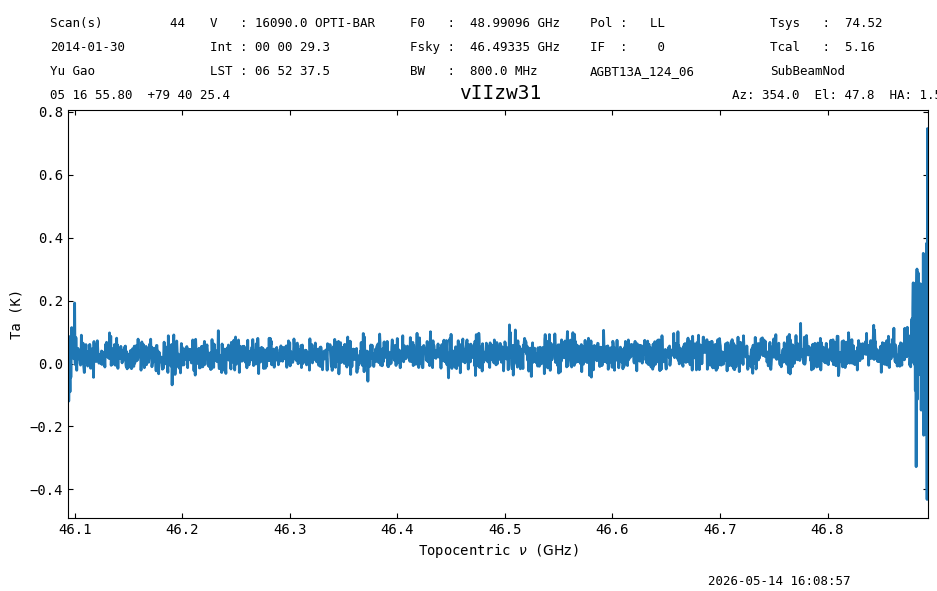

In [8]:
ta.plot(xaxis_unit="GHz");

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


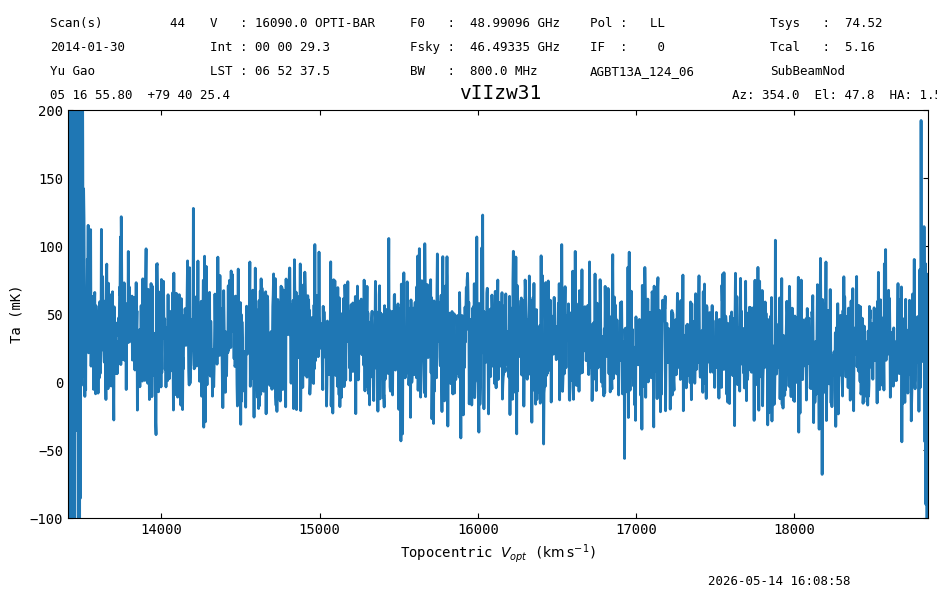

In [9]:
ta.plot(xaxis_unit="km/s", yaxis_unit="mK", ymin=-100, ymax=200);

In [10]:
sbn_scan_block2 = sdfits.subbeamnod(scan=44, fdnum=1, ifnum=0, plnum=0, method='scan')

In [11]:
ta2 = sbn_scan_block2.timeaverage()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


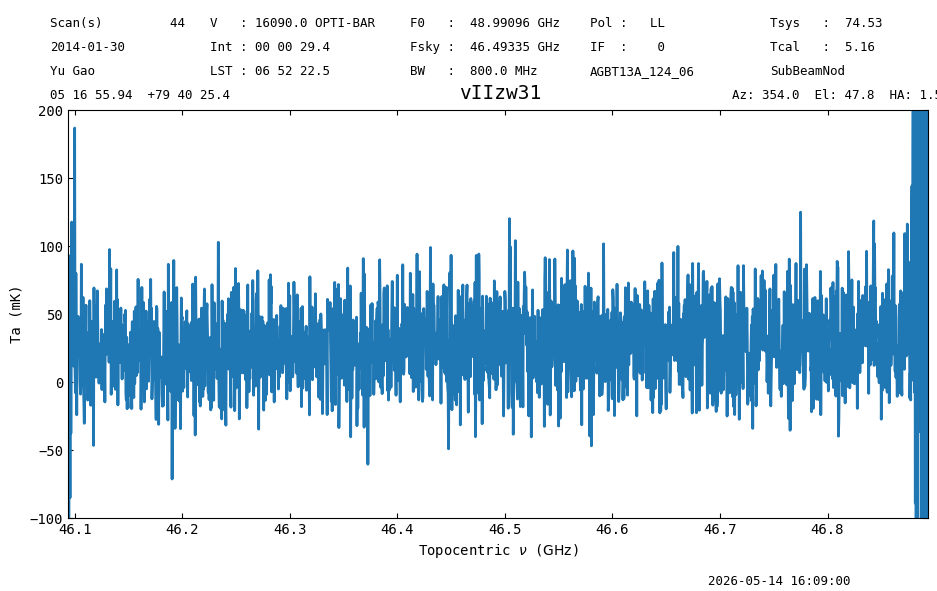

In [12]:
ta2.plot(xaxis_unit="GHz", yaxis_unit="mK", ymin=-100, ymax=200);

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


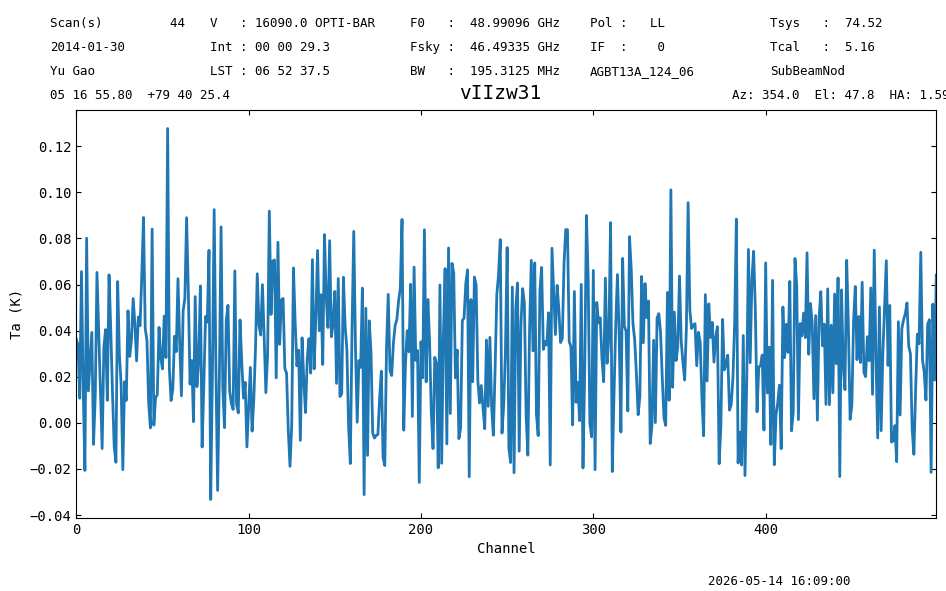

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


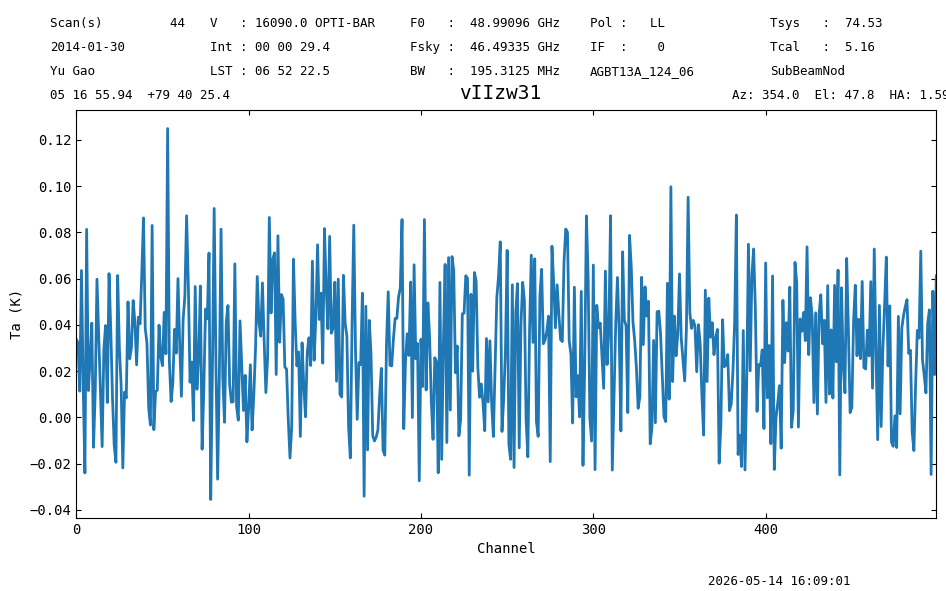

np.float64(1.2630467493960773)

In [13]:
ta[250:750].plot(xaxis_unit="chan").spectrum.radiometer() # 1.2611058840974072
ta2[250:750].plot(xaxis_unit="chan").spectrum.radiometer() # 1.2630467493960695

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


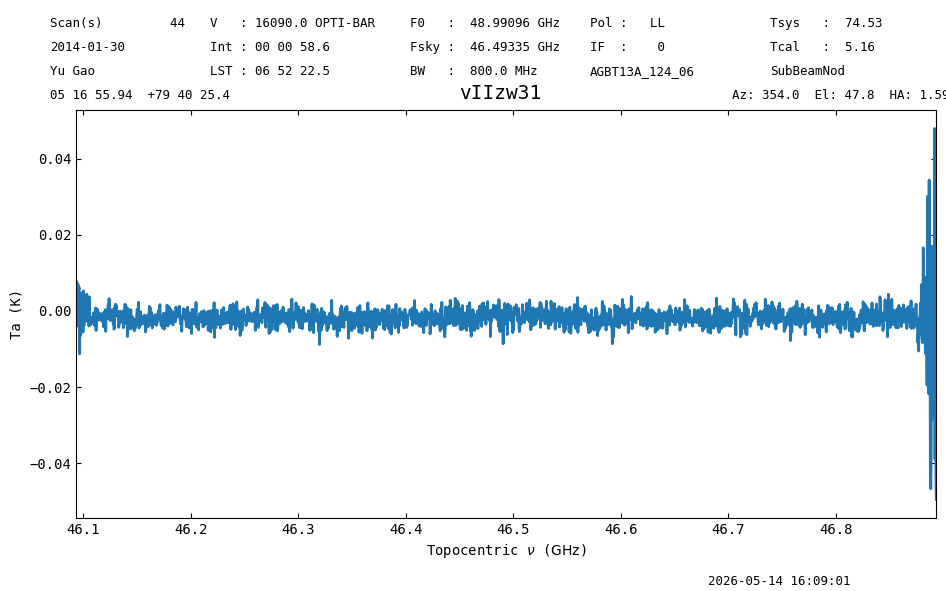

In [14]:
(ta2 - ta).plot(xaxis_unit="GHz");

In [15]:
sdfits.select(scan=44)
sdfits.selection.show()

 ID    TAG    SCAN # SELECTED
--- --------- ---- ----------
  0 b6d77b210   44       1600


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


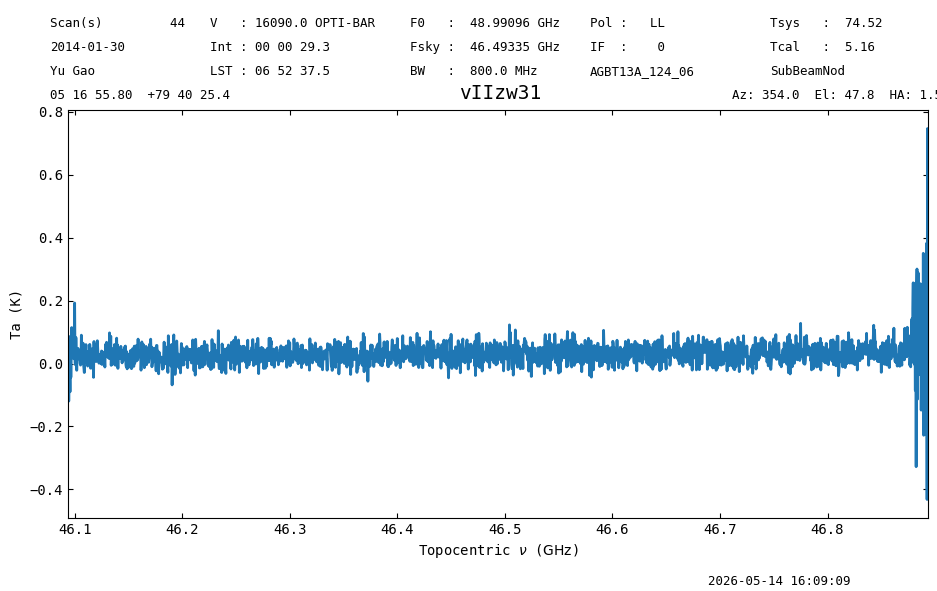

In [16]:
sbn_scan_block3 = sdfits.subbeamnod(plnum=0, fdnum=1, ifnum=0)
ta3 = sbn_scan_block3.timeaverage()
ta3.plot(xaxis_unit="GHz");

In [17]:
sbn_scan_block4 = sdfits.subbeamnod(plnum=1, fdnum=0, ifnum=0)
ta4 = sbn_scan_block4.timeaverage()
pol_avg = ta3.average(ta4)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


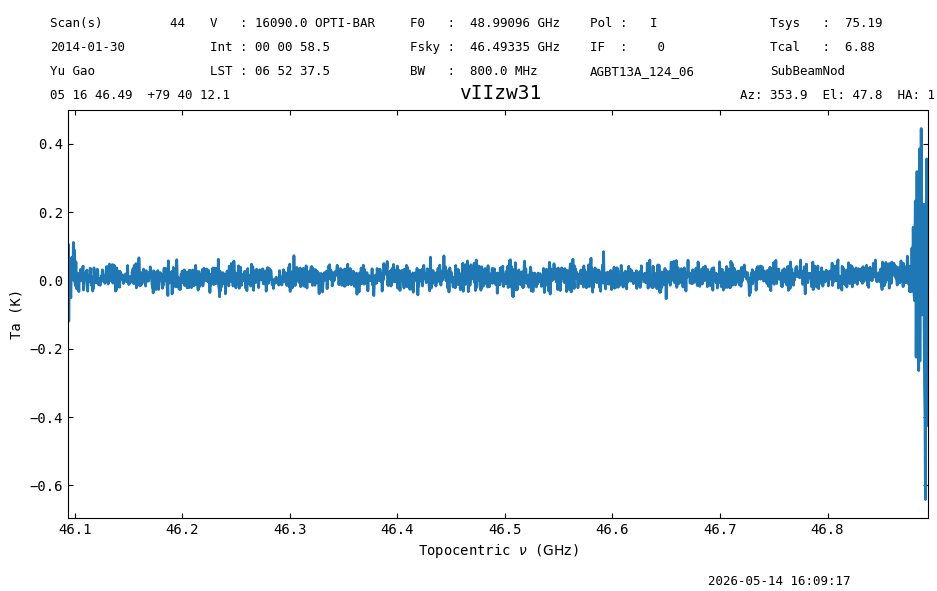

In [18]:
pol_avg.plot(xaxis_unit="GHz");

In [19]:
pol_avg.check_stats(0.03836776)

16:09:17.632 I rms is OK  (no unit was given, assumed K)


In [20]:
pol_avg[250:750].radiometer()  # 1.2538633771107366

np.float64(1.2538633771107328)